# Customer Analytics

## Análisis de clientes de una tienda de ropa

### Objetivo

Analizar el comportamiento de compra de los clientes para identificar patrones de consumo, productos destacados y características relacionadas con la fidelidad o el abandono.

In [1]:
# Manejo y análisis de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preparación y transformación de variables
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Segmentación de clientes
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Modelos predictivos
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Evaluación de modelos
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)

# Importancia de las variables
from sklearn.inspection import permutation_importance

# Configuración general
import warnings
warnings.filterwarnings("ignore")

## 1. Carga de los datos

In [2]:
ruta = "../datos/EcommData_CSV.csv"

datos = pd.read_csv(ruta, sep=";")


In [3]:
datos.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,...,Subscription Status,Shipping Type,Promo Code Used,Previous Purchases,Payment Method,Purchase Date,WeekdayNum,Weekday,Weekend,Churn
0,1,55,Male,Belt,Accessories,"46,9",Kentucky,L,Gray,Winter,...,Yes,Standard,0,14,Credit Card,7.01.2022,5,Friday,0,1
1,1,55,Male,Sweater,Clothing,"48,1",Kentucky,L,Green,Spring,...,Yes,Free Shipping,0,14,Credit Card,19.03.2022,6,Saturday,1,1
2,1,55,Male,Sweater,Clothing,"62,1",Kentucky,L,Green,Spring,...,Yes,Next Day Air,0,14,Debit Card,3.05.2022,2,Tuesday,0,1
3,1,55,Male,Belt,Accessories,"25,0",Kentucky,L,Turquoise,Summer,...,Yes,Free Shipping,0,14,Credit Card,7.05.2022,6,Saturday,1,1
4,1,55,Male,Sweater,Clothing,"89,8",Kentucky,L,Blue,Summer,...,Yes,2-Day Shipping,0,14,Google Pay,10.06.2022,5,Friday,0,1


## 2. Exploración inicial

In [4]:
datos.shape

(102771, 21)

In [5]:
datos.columns.tolist()

['Customer ID',
 'Age',
 'Gender',
 'Item Purchased',
 'Category',
 'Purchase Amount (USD)',
 'Location',
 'Size',
 'Color',
 'Season',
 'Review Rating',
 'Subscription Status',
 'Shipping Type',
 'Promo Code Used',
 'Previous Purchases',
 'Payment Method',
 'Purchase Date',
 'WeekdayNum',
 'Weekday',
 'Weekend',
 'Churn']

In [6]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 102771 entries, 0 to 102770
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype
---  ------                 --------------   -----
 0   Customer ID            102771 non-null  int64
 1   Age                    102771 non-null  int64
 2   Gender                 102771 non-null  str  
 3   Item Purchased         102771 non-null  str  
 4   Category               102771 non-null  str  
 5   Purchase Amount (USD)  102771 non-null  str  
 6   Location               102771 non-null  str  
 7   Size                   102771 non-null  str  
 8   Color                  102771 non-null  str  
 9   Season                 102771 non-null  str  
 10  Review Rating          102771 non-null  str  
 11  Subscription Status    102771 non-null  str  
 12  Shipping Type          102771 non-null  str  
 13  Promo Code Used        102771 non-null  int64
 14  Previous Purchases     102771 non-null  int64
 15  Payment Method         10277

In [7]:
datos.isnull().sum()

Customer ID              0
Age                      0
Gender                   0
Item Purchased           0
Category                 0
Purchase Amount (USD)    0
Location                 0
Size                     0
Color                    0
Season                   0
Review Rating            0
Subscription Status      0
Shipping Type            0
Promo Code Used          0
Previous Purchases       0
Payment Method           0
Purchase Date            0
WeekdayNum               0
Weekday                  0
Weekend                  0
Churn                    0
dtype: int64

**Resultado:** El dataset no presenta valores faltantes detectados por Pandas.

In [8]:
datos.duplicated().sum()

np.int64(0)

**Resultado:** No se encontraron filas completamente duplicadas en el dataset.

In [9]:
datos.describe()

,Customer ID,Age,Promo Code Used,Previous Purchases,WeekdayNum,Weekend,Churn
count,102771.000000,102771.000000,102771.000000,102771.000000,102771.000000,102771.000000,102771.000000
mean,1926.333148,44.405581,0.131924,33.270086,4.571630,0.384262,0.073455
std,1128.988782,15.187901,0.338410,12.096314,1.864296,0.486423,0.260882
min,1.000000,18.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,945.000000,31.000000,0.000000,25.000000,3.000000,0.000000,0.000000
50%,1921.000000,45.000000,0.000000,35.000000,5.000000,0.000000,0.000000
75%,2888.000000,57.000000,0.000000,44.000000,6.000000,1.000000,0.000000
max,3900.000000,70.000000,1.000000,50.000000,7.000000,1.000000,1.000000


### Verificación de variables codificadas

In [10]:
datos[["Promo Code Used", "WeekdayNum", "Weekend", "Churn"]].nunique()

Promo Code Used    2
WeekdayNum         7
Weekend            2
Churn              2
dtype: int64

In [11]:
for columna in ["Promo Code Used", "WeekdayNum", "Weekend", "Churn"]:
    print(columna, ":", datos[columna].unique())

Promo Code Used : [0 1]
WeekdayNum : [5 6 2 7 3 4 1]
Weekend : [0 1]
Churn : [1 0]


**Resultado:** Las variables codificadas presentan los valores esperados. Las variables binarias contienen 0 y 1, mientras que WeekdayNum contiene valores del 1 al 7.

In [12]:
datos["Customer ID"].nunique()

3900

### Cantidad de registros por cliente

In [13]:
datos["Customer ID"].value_counts().head(10)

Customer ID
21     51
79     51
102    51
125    51
141    51
159    51
291    51
311    51
314    51
366    51
Name: count, dtype: int64

**Resultado:** Los clientes aparecen en múltiples filas. Los clientes mostrados con mayor frecuencia tienen 51 registros cada uno, por lo que cada fila no representa un cliente único.

In [14]:
datos["Customer ID"].value_counts().mean()

np.float64(26.35153846153846)

Cada cliente aparece, en promedio, unas 26 veces en el dataset.

In [15]:
registros_por_cliente = datos["Customer ID"].value_counts()

registros_por_cliente.describe()

count    3900.000000
mean       26.351538
std        14.447125
min         2.000000
25%        14.000000
50%        26.000000
75%        39.000000
max        51.000000
Name: count, dtype: float64

**Resultado:** El dataset contiene 3.900 clientes diferentes. Cada cliente aparece, en promedio, 26,35 veces. La cantidad de registros por cliente varía entre 2 y 51, con una mediana de 26 registros.

### Revisión de los registros de un cliente

In [16]:
cliente_ejemplo = datos[datos["Customer ID"] == 21]

cliente_ejemplo.head(10)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,...,Subscription Status,Shipping Type,Promo Code Used,Previous Purchases,Payment Method,Purchase Date,WeekdayNum,Weekday,Weekend,Churn
522,21,21,Male,Sweater,Clothing,"33,6",Louisiana,M,White,Winter,...,Yes,Standard,0,50,PayPal,10.06.2022,5,Friday,0,0
523,21,21,Male,Belt,Accessories,"20,7",Louisiana,M,Blue,Summer,...,Yes,Standard,0,50,Debit Card,11.06.2022,6,Saturday,1,0
524,21,21,Male,Sneakers,Footwear,"60,1",Louisiana,M,White,Winter,...,Yes,Standard,0,50,Credit Card,18.06.2022,6,Saturday,1,0
525,21,21,Male,Sweater,Clothing,"76,9",Louisiana,M,Navy,Fall,...,Yes,Free Shipping,0,50,Credit Card,4.07.2022,1,Monday,0,0
526,21,21,Male,Sweater,Clothing,"47,1",Louisiana,M,Brown,Fall,...,Yes,Standard,0,50,Credit Card,22.07.2022,5,Friday,0,0
527,21,21,Male,Sweater,Clothing,"63,5",Louisiana,M,White,Winter,...,Yes,Express,0,50,Credit Card,30.07.2022,6,Saturday,1,0
528,21,21,Male,Sweater,Clothing,"23,8",Louisiana,M,Gray,Fall,...,Yes,Standard,0,50,Bank Transfer,3.08.2022,3,Wednesday,0,0
529,21,21,Male,Sneakers,Footwear,"35,4",Louisiana,M,White,Summer,...,Yes,Next Day Air,0,50,PayPal,23.08.2022,2,Tuesday,0,0
530,21,21,Male,Sweater,Clothing,"42,1",Louisiana,M,Red,Winter,...,Yes,Express,1,50,Credit Card,25.08.2022,4,Thursday,0,0
531,21,21,Male,Sweater,Clothing,"95,3",Louisiana,M,White,Spring,...,Yes,Standard,1,50,Credit Card,2.09.2022,5,Friday,0,0


**Unidad de análisis:** Cada fila representa el registro de la compra de un producto realizada por un cliente. Un mismo cliente puede aparecer en múltiples filas debido a que realizó varias compras.

In [17]:
datos.select_dtypes(include="object").nunique().sort_values()

Gender                      2
Subscription Status         2
Season                      4
Category                    4
Size                        4
Shipping Type               5
Weekday                     7
Item Purchased              8
Payment Method              8
Review Rating               9
Color                      18
Location                   50
Purchase Amount (USD)     861
Purchase Date            1096
dtype: int64

In [18]:
columnas_texto = datos.select_dtypes(include="object").columns

for columna in columnas_texto:
    print(f"\n{columna}:")
    print(datos[columna].unique())


Gender:
<StringArray>
['Male', 'Female']
Length: 2, dtype: str

Item Purchased:
<StringArray>
['Belt', 'Sweater', 'Coat', 'Sneakers', 'Jacket', 'Blouse', 'Sandals',
 'Handbag']
Length: 8, dtype: str

Category:
<StringArray>
['Accessories', 'Clothing', 'Outerwear', 'Footwear']
Length: 4, dtype: str

Purchase Amount (USD):
<StringArray>
['46,9', '48,1', '62,1', '25,0', '89,8', '70,3', '84,6', '27,6', '44,6',
 '22,3',
 ...
 '15,5', '13,6', '17,5', '14,5', '17,0', '14,6', '13,9', '17,7', '14,3',
 '13,2']
Length: 861, dtype: str

Location:
<StringArray>
[      'Kentucky',          'Maine',  'Massachusetts',   'Rhode Island',
         'Oregon',        'Wyoming',        'Montana',      'Louisiana',
  'West Virginia',       'Missouri',       'Arkansas',         'Hawaii',
       'Delaware',  'New Hampshire',       'New York',        'Alabama',
    'Mississippi', 'North Carolina',     'California',       'Oklahoma',
        'Florida',          'Texas',         'Nevada',         'Kansas',
      

## 3. Limpieza y preparación de los datos

In [19]:
datos_limpios = datos.copy()

In [20]:
datos_limpios["Purchase Amount (USD)"] = (
    datos_limpios["Purchase Amount (USD)"]
    .str.replace(",", ".", regex=False)
    .astype(float)
)

In [21]:
datos_limpios["Purchase Amount (USD)"].dtype

dtype('float64')

**Corrección realizada:** La variable `Purchase Amount (USD)` estaba almacenada como texto debido al uso de coma decimal. Se reemplazó la coma por un punto y se convirtió la columna al tipo numérico `float64`.

In [22]:
datos_limpios["Purchase Amount (USD)"].describe()

count    102771.000000
mean         51.882230
std          20.779942
min          13.200000
25%          35.800000
50%          48.700000
75%          64.300000
max         100.000000
Name: Purchase Amount (USD), dtype: float64

**Resultado:** Los importes de compra se encuentran entre 13,20 y 100 USD. El importe promedio es de 51,88 USD y la mediana es de 48,70 USD. La mitad central de las compras se ubica entre 35,80 y 64,30 USD. No se observan importes negativos ni valores evidentemente imposibles.

In [23]:
datos_limpios.info()

<class 'pandas.DataFrame'>
RangeIndex: 102771 entries, 0 to 102770
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            102771 non-null  int64  
 1   Age                    102771 non-null  int64  
 2   Gender                 102771 non-null  str    
 3   Item Purchased         102771 non-null  str    
 4   Category               102771 non-null  str    
 5   Purchase Amount (USD)  102771 non-null  float64
 6   Location               102771 non-null  str    
 7   Size                   102771 non-null  str    
 8   Color                  102771 non-null  str    
 9   Season                 102771 non-null  str    
 10  Review Rating          102771 non-null  str    
 11  Subscription Status    102771 non-null  str    
 12  Shipping Type          102771 non-null  str    
 13  Promo Code Used        102771 non-null  int64  
 14  Previous Purchases     102771 non-null  int64  

In [24]:
datos_limpios[["Review Rating", "Purchase Date"]].head(10)

,Review Rating,Purchase Date
0,5,7.01.2022
1,1,19.03.2022
2,5,3.05.2022
3,5,7.05.2022
4,5,10.06.2022
5,"2,5",28.08.2022
6,5,1.01.2023
7,"4,5",11.02.2023
8,5,4.03.2023
9,5,5.03.2023


In [25]:
datos_limpios["Review Rating"] = (
    datos_limpios["Review Rating"]
    .str.replace(",", ".", regex=False)
    .astype(float)
)

In [26]:
datos_limpios["Purchase Date"] = pd.to_datetime(
    datos_limpios["Purchase Date"],
    format="%d.%m.%Y"
)

In [27]:
datos_limpios[["Review Rating", "Purchase Date"]].dtypes

Review Rating           float64
Purchase Date    datetime64[us]
dtype: object

**Correcciones realizadas:** La variable `Review Rating` fue convertida de texto a número decimal. La variable `Purchase Date` fue transformada al tipo fecha utilizando el formato día.mes.año.

In [28]:
datos_limpios["Review Rating"].describe()

count    102771.000000
mean          3.852283
std           1.499330
min           1.000000
25%           3.000000
50%           4.500000
75%           5.000000
max           5.000000
Name: Review Rating, dtype: float64

**Resultado:** Las calificaciones se encuentran dentro de una escala de 1 a 5. La valoración promedio es de 3,85 puntos y la mediana es de 4,5. No se observan valores fuera del rango esperado.

In [29]:
datos_limpios["Purchase Date"].agg(["min", "max"])

min   2022-01-01
max   2024-12-31
Name: Purchase Date, dtype: datetime64[us]

**Período analizado:** Las compras fueron registradas entre el 1 de enero de 2022 y el 31 de diciembre de 2024.

In [30]:
pd.crosstab(
    datos_limpios["WeekdayNum"],
    datos_limpios["Weekday"]
)

Weekday,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
WeekdayNum,,,,,,,
1,0,8543,0,0,0,0,0
2,0,0,0,0,0,10199,0
3,0,0,0,0,0,0,10181
4,0,0,0,0,15626,0,0
5,18731,0,0,0,0,0,0
6,0,0,22249,0,0,0,0
7,0,0,0,17242,0,0,0


**Resultado:** `WeekdayNum` y `Weekday` son coherentes. La codificación utilizada es 1 = Monday, 2 = Tuesday, 3 = Wednesday, 4 = Thursday, 5 = Friday, 6 = Saturday y 7 = Sunday. No se encontraron asociaciones contradictorias.

In [31]:
weekend_esperado = datos_limpios["WeekdayNum"].isin([6, 7]).astype(int)

errores_weekend = (
    datos_limpios["Weekend"] != weekend_esperado
).sum()

errores_weekend

np.int64(0)

**Resultado:** La variable `Weekend` es coherente con `WeekdayNum`. No se encontraron registros contradictorios.

In [32]:
dia_calculado = datos_limpios["Purchase Date"].dt.day_name()

errores_fecha_dia = (
    datos_limpios["Weekday"] != dia_calculado
).sum()

errores_fecha_dia

np.int64(0)

**Resultado:** No se encontraron contradicciones entre `Purchase Date` y `Weekday`. El día registrado coincide con el día real correspondiente a cada fecha.

In [33]:
print("Dimensiones originales:", datos.shape)
print("Dimensiones limpias:", datos_limpios.shape)

datos_limpios[
    ["Purchase Amount (USD)", "Review Rating", "Purchase Date"]
].isnull().sum()

Dimensiones originales: (102771, 21)
Dimensiones limpias: (102771, 21)


Purchase Amount (USD)    0
Review Rating            0
Purchase Date            0
dtype: int64

**Verificación final:** La limpieza conservó las 102.771 filas y las 21 columnas originales. Las conversiones de importe, calificación y fecha no generaron valores faltantes.

In [34]:
ruta_limpia = "../datos/ventas_clientes_limpias.csv"

datos_limpios.to_csv(
    ruta_limpia,
    index=False
)

## 4. Análisis comercial

En esta sección se analizarán los principales indicadores de ventas y comportamiento de los clientes.

## 4.1 Indicadores generales

In [35]:
ventas_totales = datos_limpios["Purchase Amount (USD)"].sum()

round(ventas_totales, 2)



np.float64(5331988.7)

In [36]:
print(f"Ventas totales: USD {ventas_totales:,.2f}")

Ventas totales: USD 5,331,988.70


**Ventas totales:** Durante el período analizado, los importes de compra acumularon un total de 5.331.988,70 USD. Este valor representa ingresos por ventas registradas y no ganancias netas.

In [37]:
datos_limpios["Year"] = datos_limpios["Purchase Date"].dt.year

In [38]:
ventas_por_anio = (
    datos_limpios
    .groupby("Year")["Purchase Amount (USD)"]
    .sum()
)

ventas_por_anio

Year
2022    1448279.5
2023    1725254.0
2024    2158455.2
Name: Purchase Amount (USD), dtype: float64

In [39]:
crecimiento_anual = ventas_por_anio.pct_change() * 100

crecimiento_anual

Year
2022          NaN
2023    19.124382
2024    25.109416
Name: Purchase Amount (USD), dtype: float64

**Evolución anual:** Las ventas aumentaron durante todo el período. Entre 2022 y 2023 crecieron un 19,12 %, mientras que entre 2023 y 2024 aumentaron un 25,11 %. En términos acumulados, las ventas de 2024 fueron aproximadamente un 49,04 % superiores a las de 2022.

In [40]:
compras_por_anio = (
    datos_limpios
    .groupby("Year")
    .size()
)

compras_por_anio

Year
2022    28174
2023    33261
2024    41336
dtype: int64

In [41]:
importe_promedio_por_anio = (
    datos_limpios
    .groupby("Year")["Purchase Amount (USD)"]
    .mean()
    .round(2)
)

importe_promedio_por_anio

Year
2022    51.40
2023    51.87
2024    52.22
Name: Purchase Amount (USD), dtype: float64

**Interpretación:** El importe promedio por registro aumentó ligeramente, pasando de 51,40 USD en 2022 a 52,22 USD en 2024. Sin embargo, este incremento fue mucho menor que el crecimiento de la cantidad de compras. Por lo tanto, el aumento de las ventas totales se explica principalmente por un mayor volumen de compras registradas.

In [42]:
clientes_por_anio = (
    datos_limpios
    .groupby("Year")["Customer ID"]
    .nunique()
)

clientes_por_anio

Year
2022    3726
2023    3730
2024    3871
Name: Customer ID, dtype: int64

In [43]:
compras_promedio_por_cliente = (
    compras_por_anio / clientes_por_anio
).round(2)

compras_promedio_por_cliente

Year
2022     7.56
2023     8.92
2024    10.68
dtype: float64

**Interpretación:** La cantidad de clientes únicos se mantuvo relativamente estable, mientras que la cantidad de compras aumentó considerablemente. Esto sugiere que el crecimiento de las ventas estuvo relacionado principalmente con una mayor actividad de compra por cliente y no solamente con la incorporación de nuevos clientes.

In [44]:
resumen_anual = pd.DataFrame({
    "Ventas totales (USD)": ventas_por_anio,
    "Compras registradas": compras_por_anio,
    "Clientes únicos": clientes_por_anio,
    "Importe promedio (USD)": importe_promedio_por_anio,
    "Compras por cliente": compras_promedio_por_cliente
})

resumen_anual

,Ventas totales (USD),Compras registradas,Clientes únicos,Importe promedio (USD),Compras por cliente
Year,,,,,
2022,1448279.5,28174,3726,51.40,7.56
2023,1725254.0,33261,3730,51.87,8.92
2024,2158455.2,41336,3871,52.22,10.68


## 4.2 Evolución anual de las ventas

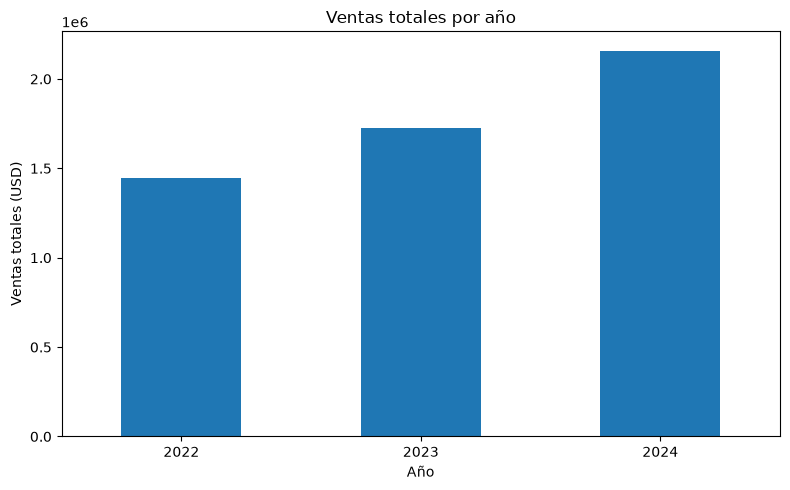

In [45]:
plt.figure(figsize=(8, 5))

ventas_por_anio.plot(kind="bar")

plt.title("Ventas totales por año")
plt.xlabel("Año")
plt.ylabel("Ventas totales (USD)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4.3 Evolución de la cantidad de compras

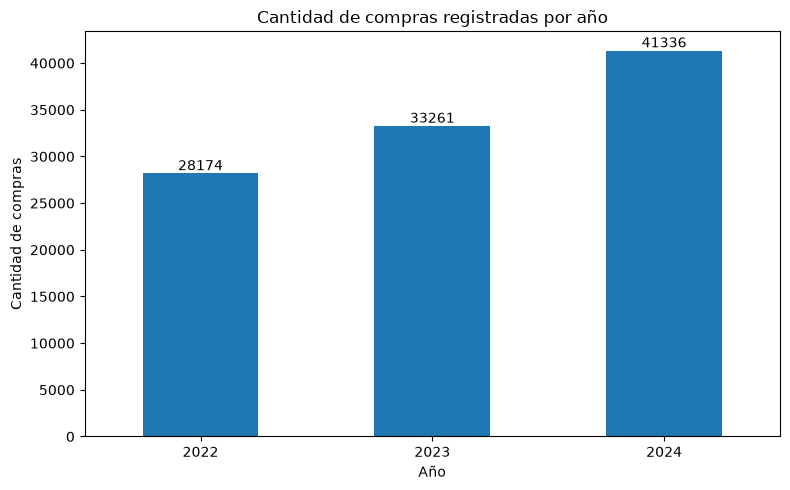

In [46]:
ax = compras_por_anio.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Cantidad de compras registradas por año")
plt.xlabel("Año")
plt.ylabel("Cantidad de compras")

plt.xticks(rotation=0)

ax.bar_label(
    ax.containers[0],
    fmt="%.0f"
)

plt.tight_layout()
plt.show()

## 4.4 Evolución mensual de las ventas

In [47]:
ventas_mensuales = (
    datos_limpios
    .groupby(datos_limpios["Purchase Date"].dt.to_period("M"))[
        "Purchase Amount (USD)"
    ]
    .sum()
)

ventas_mensuales.head(12)

Purchase Date
2022-01     85837.1
2022-02     82456.7
2022-03    115344.9
2022-04    123447.5
2022-05    131628.8
2022-06    133557.6
2022-07    119725.3
2022-08    139847.8
2022-09     76776.7
2022-10     78472.9
2022-11    157263.5
2022-12    203920.7
Freq: M, Name: Purchase Amount (USD), dtype: float64

**Resultado para 2022:** Las ventas mensuales presentaron variaciones a lo largo del año. Diciembre registró el mayor importe de ventas, con 203.920,70 USD, mientras que septiembre presentó el menor, con 76.776,70 USD. Estos resultados todavía no son suficientes para confirmar un patrón estacional.

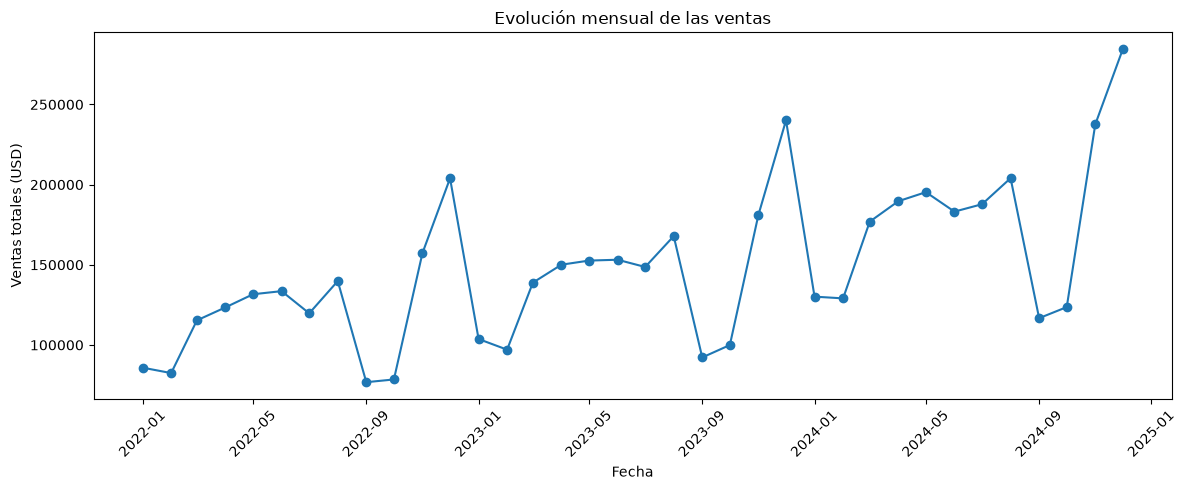

In [48]:
ventas_mensuales_grafico = ventas_mensuales.copy()

ventas_mensuales_grafico.index = (
    ventas_mensuales_grafico.index.to_timestamp()
)

plt.figure(figsize=(12, 5))

plt.plot(
    ventas_mensuales_grafico.index,
    ventas_mensuales_grafico.values,
    marker="o"
)

plt.title("Evolución mensual de las ventas")
plt.xlabel("Fecha")
plt.ylabel("Ventas totales (USD)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretación:** Las ventas mensuales muestran una tendencia general creciente, aunque con importantes variaciones entre meses. Se observan aumentos marcados hacia noviembre y diciembre y descensos alrededor de septiembre y octubre. Esto sugiere la posible existencia de un patrón estacional, que debe comprobarse comparando los mismos meses entre los distintos años.

In [49]:
datos_limpios["Month"] = datos_limpios["Purchase Date"].dt.month

ventas_mes_anio = datos_limpios.pivot_table(
    index="Month",
    columns="Year",
    values="Purchase Amount (USD)",
    aggfunc="sum"
)

ventas_mes_anio

Year,2022,2023,2024
Month,,,
1,85837.1,103695.5,130127.4
2,82456.7,97055.6,129049.9
3,115344.9,138863.0,176910.0
4,123447.5,150056.7,189648.6
5,131628.8,152619.4,195302.0
6,133557.6,153151.0,183158.9
7,119725.3,148635.7,187776.8
8,139847.8,167867.8,204026.2
9,76776.7,92212.8,116707.3


**Interpretación:** Las ventas presentan una tendencia creciente entre 2022 y 2024 y, al mismo tiempo, un patrón estacional. Septiembre fue el mes con menores ventas en los tres años, mientras que diciembre fue el mes con mayores ventas. También se observa una recuperación marcada durante noviembre. Por lo tanto, las variaciones mensuales no parecen completamente aleatorias, sino que siguen un patrón que se repite anualmente.

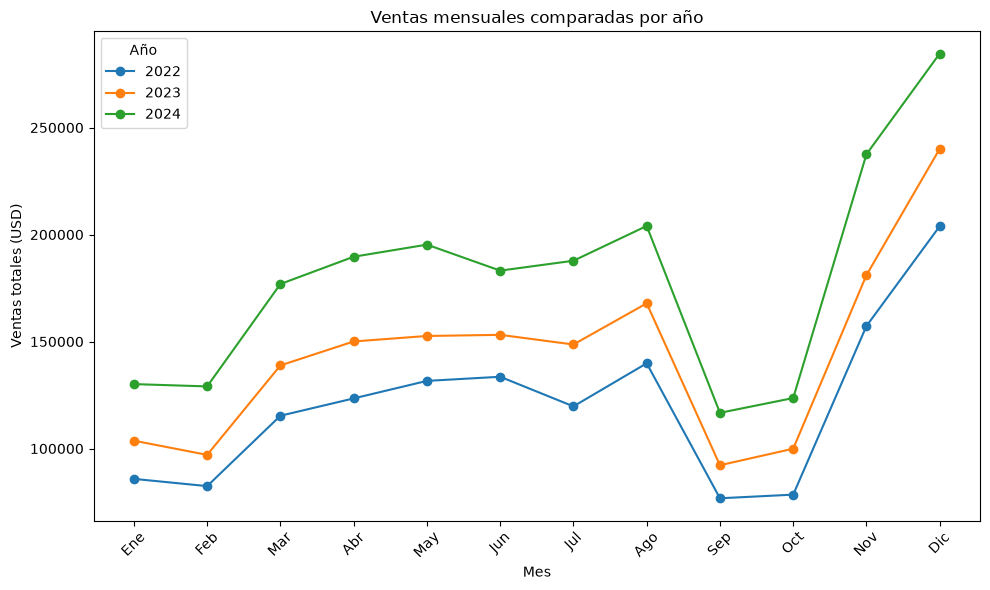

In [50]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

ventas_mes_anio.plot(
    kind="line",
    marker="o",
    ax=ax
)

ax.set_title("Ventas mensuales comparadas por año")
ax.set_xlabel("Mes")
ax.set_ylabel("Ventas totales (USD)")

ax.set_xticks(range(1, 13))
ax.set_xticklabels(
    [
        "Ene", "Feb", "Mar", "Abr",
        "May", "Jun", "Jul", "Ago",
        "Sep", "Oct", "Nov", "Dic"
    ],
    rotation=45
)

ax.legend(title="Año")
fig.tight_layout()

fig.savefig(
    "../grafico_ventas.jpg",
    format="jpg",
    dpi=200,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

## 4.5 Análisis de ventas por categoría

In [51]:
ventas_por_categoria = (
    datos_limpios
    .groupby("Category")["Purchase Amount (USD)"]
    .sum()
    .sort_values(ascending=False)
)

ventas_por_categoria

Category
Clothing       3591140.7
Footwear        900332.9
Accessories     471879.0
Outerwear       368636.1
Name: Purchase Amount (USD), dtype: float64

**Interpretación:** `Clothing` fue la categoría con mayores ventas, acumulando 3.591.140,70 USD y representando aproximadamente el 67,35 % de las ventas totales. Le siguieron `Footwear`, `Accessories` y `Outerwear`. Esto indica una fuerte concentración de las ventas en la categoría de ropa, aunque no permite determinar cuál fue la más rentable porque el dataset no incluye costos.

In [52]:
compras_por_categoria = (
    datos_limpios
    .groupby("Category")
    .size()
    .sort_values(ascending=False)
)

compras_por_categoria

Category
Clothing       69504
Footwear       17399
Accessories     9083
Outerwear       6785
dtype: int64

In [53]:
importe_promedio_por_categoria = (
    datos_limpios
    .groupby("Category")["Purchase Amount (USD)"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

importe_promedio_por_categoria

Category
Outerwear      54.33
Accessories    51.95
Footwear       51.75
Clothing       51.67
Name: Purchase Amount (USD), dtype: float64

**Interpretación:** `Outerwear` presentó el importe promedio más alto, con 54,33 USD por registro. Sin embargo, `Clothing` concentró la mayor facturación debido a que tuvo una cantidad de compras muy superior. Por lo tanto, el liderazgo de `Clothing` se explica principalmente por el volumen de ventas y no por un importe promedio más alto.

In [54]:
resumen_categorias = pd.DataFrame({
    "Ventas totales (USD)": ventas_por_categoria,
    "Compras registradas": compras_por_categoria,
    "Importe promedio (USD)": importe_promedio_por_categoria
})

resumen_categorias

,Ventas totales (USD),Compras registradas,Importe promedio (USD)
Category,,,
Accessories,471879.0,9083,51.95
Clothing,3591140.7,69504,51.67
Footwear,900332.9,17399,51.75
Outerwear,368636.1,6785,54.33


### Ventas totales por categoría

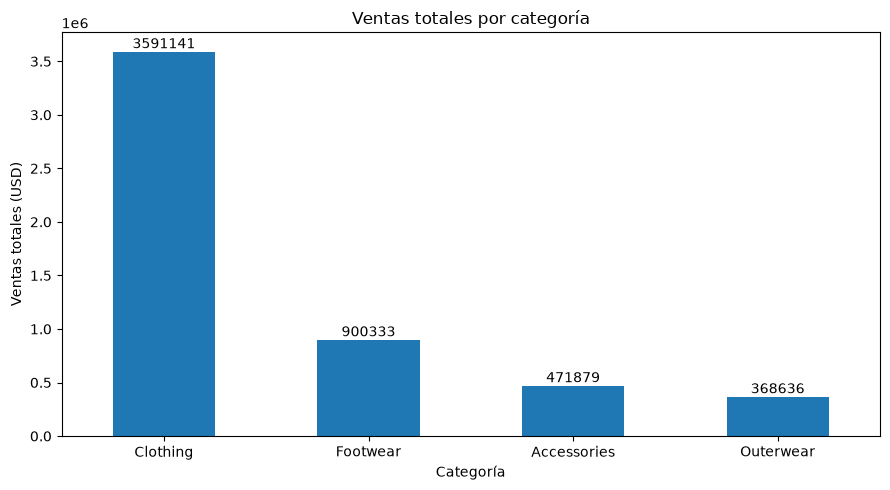

In [104]:
ax = ventas_por_categoria.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Ventas totales por categoría")
plt.xlabel("Categoría")
plt.ylabel("Ventas totales (USD)")

plt.xticks(rotation=0)

ax.bar_label(
    ax.containers[0],
    fmt="%.0f"
)

plt.tight_layout()
plt.savefig(
    "../imagenes/ventas_por_categoria.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 4.6 Análisis de ventas por producto

In [56]:
ventas_por_producto = (
    datos_limpios
    .groupby("Item Purchased")["Purchase Amount (USD)"]
    .sum()
    .sort_values(ascending=False)
)

ventas_por_producto

Item Purchased
Sweater     2289417.8
Blouse      1301722.9
Sneakers     555365.1
Sandals      344967.8
Belt         342826.1
Jacket       220463.7
Coat         148172.4
Handbag      129052.9
Name: Purchase Amount (USD), dtype: float64

**Interpretación:** `Sweater` fue el producto con mayores ventas acumuladas, representando aproximadamente el 42,94 % de las ventas totales. Le siguió `Blouse`, con un 24,41 %. Entre ambos productos concentraron aproximadamente el 67,35 % de la facturación registrada.

In [57]:
compras_por_producto = (
    datos_limpios
    .groupby("Item Purchased")
    .size()
    .sort_values(ascending=False)
)

compras_por_producto

Item Purchased
Sweater     43661
Blouse      25843
Sneakers    10587
Sandals      6812
Belt         6593
Jacket       4119
Coat         2666
Handbag      2490
dtype: int64

In [58]:
importe_promedio_por_producto = (
    datos_limpios
    .groupby("Item Purchased")["Purchase Amount (USD)"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

importe_promedio_por_producto

Item Purchased
Coat        55.58
Jacket      53.52
Sneakers    52.46
Sweater     52.44
Belt        52.00
Handbag     51.83
Sandals     50.64
Blouse      50.37
Name: Purchase Amount (USD), dtype: float64

**Interpretación:** `Coat` presentó el importe promedio más alto, con 55,58 USD por registro. Sin embargo, `Sweater` y `Blouse` fueron los productos con mayor facturación debido a su elevado volumen de compras. Las diferencias entre los importes promedio de los productos fueron relativamente pequeñas, por lo que la cantidad de compras fue el principal factor que determinó las ventas totales.

In [59]:
resumen_productos = pd.DataFrame({
    "Ventas totales (USD)": ventas_por_producto,
    "Compras registradas": compras_por_producto,
    "Importe promedio (USD)": importe_promedio_por_producto
})

resumen_productos

,Ventas totales (USD),Compras registradas,Importe promedio (USD)
Item Purchased,,,
Belt,342826.1,6593,52.00
Blouse,1301722.9,25843,50.37
Coat,148172.4,2666,55.58
Handbag,129052.9,2490,51.83
Jacket,220463.7,4119,53.52
Sandals,344967.8,6812,50.64
Sneakers,555365.1,10587,52.46
Sweater,2289417.8,43661,52.44


### Ventas totales por producto

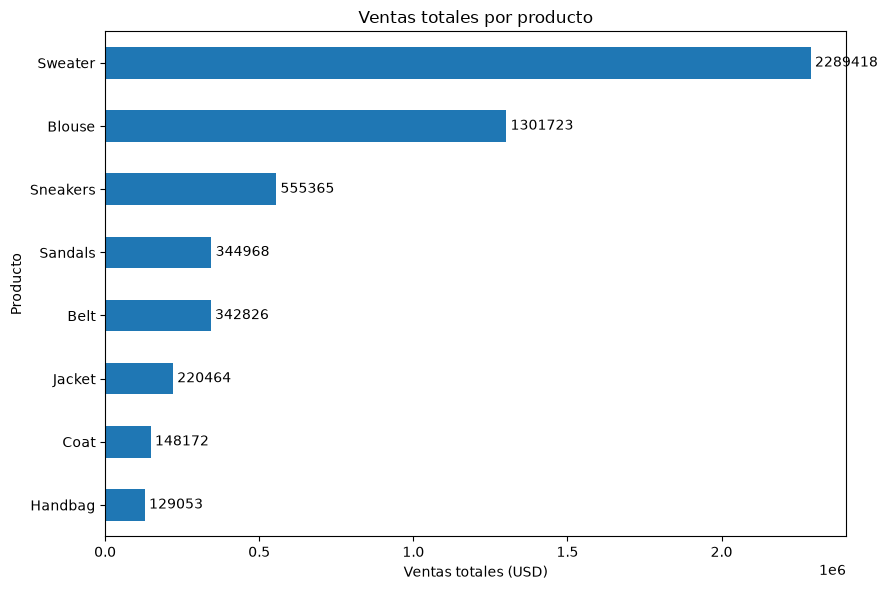

In [60]:
ax = ventas_por_producto.sort_values().plot(
    kind="barh",
    figsize=(9, 6)
)

plt.title("Ventas totales por producto")
plt.xlabel("Ventas totales (USD)")
plt.ylabel("Producto")

ax.bar_label(
    ax.containers[0],
    fmt="%.0f",
    padding=3
)

plt.tight_layout()
plt.show()

## 4.7 Preparación del análisis por cliente

In [61]:
columnas_cliente = [
    "Age",
    "Gender",
    "Location",
    "Subscription Status",
    "Churn"
]

consistencia_cliente = (
    datos_limpios
    .groupby("Customer ID")[columnas_cliente]
    .nunique()
    .max()
)

consistencia_cliente

Age                    1
Gender                 1
Location               1
Subscription Status    1
Churn                  1
dtype: int64

**Resultado:** Los datos personales de los clientes son consistentes entre sus diferentes registros de compra. Cada cliente presenta un único valor de edad, género, ubicación, suscripción y abandono.

In [62]:
resumen_clientes = (
    datos_limpios
    .groupby("Customer ID")
    .agg(
        edad=("Age", "first"),
        genero=("Gender", "first"),
        ubicacion=("Location", "first"),
        suscripcion=("Subscription Status", "first"),
        abandono=("Churn", "first"),
        compras_registradas=("Item Purchased", "size"),
        gasto_total_usd=("Purchase Amount (USD)", "sum"),
        gasto_promedio_usd=("Purchase Amount (USD)", "mean"),
        primera_compra=("Purchase Date", "min"),
        ultima_compra=("Purchase Date", "max")
    )
    .reset_index()
)

resumen_clientes[
    ["gasto_total_usd", "gasto_promedio_usd"]
] = resumen_clientes[
    ["gasto_total_usd", "gasto_promedio_usd"]
].round(2)

resumen_clientes.shape

(3900, 11)

In [63]:
resumen_clientes.head()

,Customer ID,edad,genero,ubicacion,suscripcion,abandono,compras_registradas,gasto_total_usd,gasto_promedio_usd,primera_compra,ultima_compra
0,1,55,Male,Kentucky,Yes,1,15,857.9,57.19,2022-01-07,2024-07-09
1,2,19,Male,Maine,Yes,0,3,188.5,62.83,2023-09-01,2024-11-20
2,3,50,Male,Massachusetts,Yes,0,24,1262.4,52.60,2022-04-04,2024-12-29
3,4,21,Male,Rhode Island,Yes,0,50,2675.0,53.50,2022-01-01,2024-12-31
4,5,45,Male,Oregon,Yes,0,32,1785.5,55.80,2022-01-01,2024-12-27


In [64]:
resumen_clientes[
    [
        "edad",
        "compras_registradas",
        "gasto_total_usd",
        "gasto_promedio_usd"
    ]
].describe().round(2)

,edad,compras_registradas,gasto_total_usd,gasto_promedio_usd
count,3900.00,3900.00,3900.00,3900.00
mean,44.07,26.35,1367.18,51.91
std,15.21,14.45,760.32,5.98
min,18.00,2.00,44.30,22.15
25%,31.00,14.00,719.20,48.49
50%,44.00,26.00,1360.70,51.65
75%,57.00,39.00,2016.58,55.07
max,70.00,51.00,3082.70,97.75


**Interpretación:** Los 3.900 clientes tienen una edad promedio de 44,07 años. Cada cliente registra, en promedio, 26,35 compras y un gasto total de 1.367,18 USD. El gasto promedio por registro es relativamente estable entre clientes, mientras que la cantidad de compras y el gasto total presentan diferencias importantes. Esto sugiere que el valor económico de un cliente depende principalmente de su frecuencia de compra.

In [65]:
clientes_por_abandono = resumen_clientes["abandono"].value_counts().sort_index()

porcentaje_abandono = (
    resumen_clientes["abandono"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("Cantidad de clientes:")
print(clientes_por_abandono)

print("\nPorcentaje de clientes:")
print(porcentaje_abandono)

Cantidad de clientes:
abandono
0    3566
1     334
Name: count, dtype: int64

Porcentaje de clientes:
abandono
0    91.44
1     8.56
Name: proportion, dtype: float64


**Abandono de clientes:** De los 3.900 clientes analizados, 334 fueron identificados como clientes que abandonaron, lo que representa una tasa de abandono del 8,56 %. La mayoría de los clientes, el 91,44 %, no abandonó. Para este análisis se utilizó una fila por cliente, evitando contar varias veces a quienes realizaron múltiples compras.

In [66]:
comparacion_abandono = (
    resumen_clientes
    .groupby("abandono")
    .agg(
        clientes=("Customer ID", "count"),
        edad_promedio=("edad", "mean"),
        compras_promedio=("compras_registradas", "mean"),
        gasto_total_promedio=("gasto_total_usd", "mean"),
        gasto_por_compra_promedio=("gasto_promedio_usd", "mean")
    )
    .round(2)
)

comparacion_abandono

,clientes,edad_promedio,compras_promedio,gasto_total_promedio,gasto_por_compra_promedio
abandono,,,,,
0,3566,44.15,26.7,1389.73,52.05
1,334,43.19,22.6,1126.43,50.43


**Interpretación:** Los clientes que abandonaron realizaron menos compras y presentaron un gasto total promedio inferior. En cambio, las diferencias en edad y gasto promedio por compra fueron pequeñas. Esto sugiere que el abandono está más relacionado con una menor frecuencia de compra que con el importe gastado en cada ocasión. Estos resultados son descriptivos y no demuestran causalidad.

In [67]:
abandono_por_suscripcion = (
    pd.crosstab(
        resumen_clientes["suscripcion"],
        resumen_clientes["abandono"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

abandono_por_suscripcion

abandono,0,1
suscripcion,,
No,91.18,8.82
Yes,92.12,7.88


**Suscripción y abandono:** La tasa de abandono fue del 8,82 % entre los clientes sin suscripción y del 7,88 % entre quienes tenían una suscripción. Los clientes suscriptos presentaron una tasa de abandono ligeramente menor, con una diferencia de 0,94 puntos porcentuales. Esta diferencia es descriptiva y no demuestra que la suscripción sea la causa de una mayor permanencia.

In [68]:
cantidad_abandono_suscripcion = pd.crosstab(
    resumen_clientes["suscripcion"],
    resumen_clientes["abandono"]
)

cantidad_abandono_suscripcion

abandono,0,1
suscripcion,,
No,2596,251
Yes,970,83


## 5. Segmentación de clientes

En esta sección se agruparán los clientes según su comportamiento de compra, utilizando indicadores de recencia, frecuencia y gasto.

In [69]:
fecha_referencia = datos_limpios["Purchase Date"].max()

resumen_clientes["recencia_dias"] = (
    fecha_referencia - resumen_clientes["ultima_compra"]
).dt.days

print("Fecha de referencia:", fecha_referencia)

resumen_clientes[
    ["Customer ID", "ultima_compra", "recencia_dias"]
].head()

Fecha de referencia: 2024-12-31 00:00:00


,Customer ID,ultima_compra,recencia_dias
0,1,2024-07-09,175
1,2,2024-11-20,41
2,3,2024-12-29,2
3,4,2024-12-31,0
4,5,2024-12-27,4


**Recencia:** Se calculó la cantidad de días transcurridos desde la última compra de cada cliente hasta el 31 de diciembre de 2024. Una recencia baja indica que el cliente compró recientemente, mientras que una recencia alta indica un período prolongado sin compras.

In [70]:
datos_rfm = resumen_clientes[
    [
        "Customer ID",
        "recencia_dias",
        "compras_registradas",
        "gasto_total_usd"
    ]
].copy()

datos_rfm.head()

,Customer ID,recencia_dias,compras_registradas,gasto_total_usd
0,1,175,15,857.9
1,2,41,3,188.5
2,3,2,24,1262.4
3,4,0,50,2675.0
4,5,4,32,1785.5


In [71]:
datos_rfm[
    [
        "recencia_dias",
        "compras_registradas",
        "gasto_total_usd"
    ]
].describe().round(2)

,recencia_dias,compras_registradas,gasto_total_usd
count,3900.00,3900.00,3900.00
mean,46.02,26.35,1367.18
std,74.99,14.45,760.32
min,0.00,2.00,44.30
25%,5.00,14.00,719.20
50%,16.00,26.00,1360.70
75%,44.00,39.00,2016.58
max,788.00,51.00,3082.70


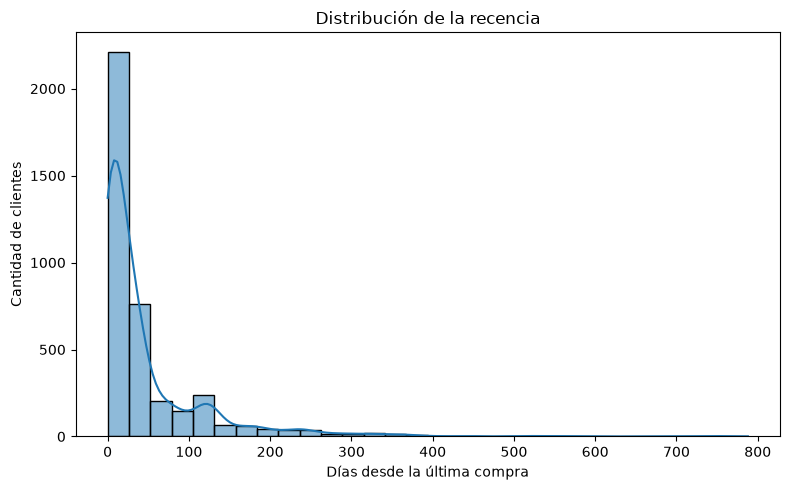

In [72]:
plt.figure(figsize=(8, 5))

sns.histplot(
    datos_rfm["recencia_dias"],
    bins=30,
    kde=True
)

plt.title("Distribución de la recencia")
plt.xlabel("Días desde la última compra")
plt.ylabel("Cantidad de clientes")

plt.tight_layout()
plt.show()

**Interpretación:** La recencia presenta una distribución asimétrica hacia la derecha. La mayoría de los clientes realizó su última compra recientemente, mientras que un grupo reducido lleva varios meses o incluso más de dos años sin comprar. Estos clientes inactivos generan una cola larga y elevan el promedio de recencia.

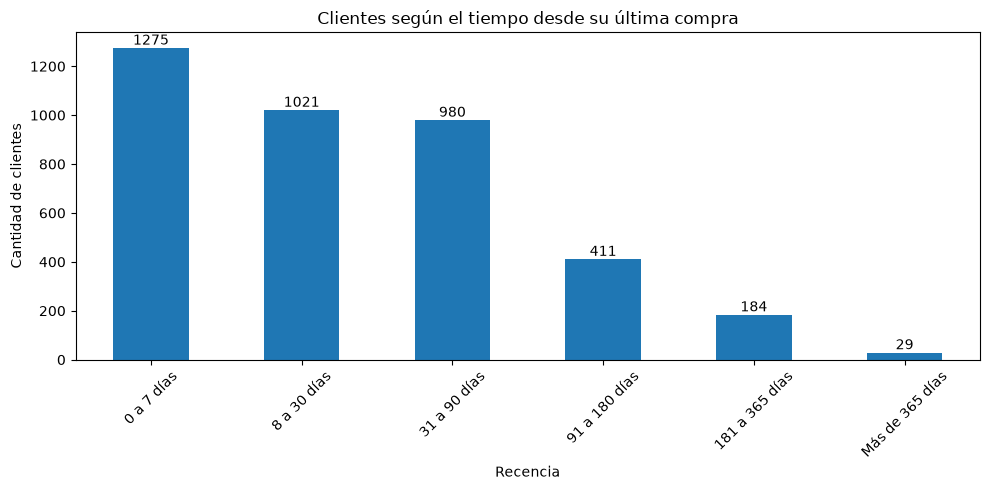

In [105]:
rangos_recencia = pd.cut(
    datos_rfm["recencia_dias"],
    bins=[-1, 7, 30, 90, 180, 365, float("inf")],
    labels=[
        "0 a 7 días",
        "8 a 30 días",
        "31 a 90 días",
        "91 a 180 días",
        "181 a 365 días",
        "Más de 365 días"
    ]
)

clientes_por_recencia = rangos_recencia.value_counts().sort_index()

ax = clientes_por_recencia.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Clientes según el tiempo desde su última compra")
plt.xlabel("Recencia")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=45)

ax.bar_label(ax.containers[0], fmt="%.0f")

plt.tight_layout()
plt.savefig(
    "../imagenes/recencia_clientes.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [74]:
datos_rfm_modelo = datos_rfm.copy()

datos_rfm_modelo["recencia_log"] = np.log1p(
    datos_rfm_modelo["recencia_dias"]
)

datos_rfm_modelo[
    ["recencia_dias", "recencia_log"]
].head()

,recencia_dias,recencia_log
0,175,5.170484
1,41,3.737670
2,2,1.098612
3,0,0.000000
4,4,1.609438


In [75]:
variables_modelo = datos_rfm_modelo[
    [
        "recencia_log",
        "compras_registradas",
        "gasto_total_usd"
    ]
]

correlaciones_rfm = variables_modelo.corr().round(2)

correlaciones_rfm

,recencia_log,compras_registradas,gasto_total_usd
recencia_log,1.00,-0.47,-0.50
compras_registradas,-0.47,1.00,0.99
gasto_total_usd,-0.50,0.99,1.00


**Selección de variables:** La frecuencia de compra y el gasto total presentaron una correlación de 0,99, lo que indica que ambas variables contienen información prácticamente redundante. Para evitar darle un peso duplicado al nivel de actividad, la segmentación se realizará utilizando recencia y frecuencia. El gasto total se conservará para describir e interpretar económicamente los grupos obtenidos.

In [76]:
variables_cluster = datos_rfm_modelo[
    [
        "recencia_log",
        "compras_registradas"
    ]
]

escalador = StandardScaler()

variables_escaladas = escalador.fit_transform(
    variables_cluster
)

datos_escalados = pd.DataFrame(
    variables_escaladas,
    columns=variables_cluster.columns
)

datos_escalados.describe().round(2)

,recencia_log,compras_registradas
count,3900.00,3900.00
mean,-0.00,0.00
std,1.00,1.00
min,-2.07,-1.69
25%,-0.80,-0.86
50%,-0.06,-0.02
75%,0.63,0.88
max,2.66,1.71


**Estandarización:** Las variables utilizadas para la segmentación fueron transformadas mediante `StandardScaler`. Ambas quedaron con media cercana a cero y desvío estándar cercano a uno, evitando que una variable influya más que otra únicamente por su escala numérica.

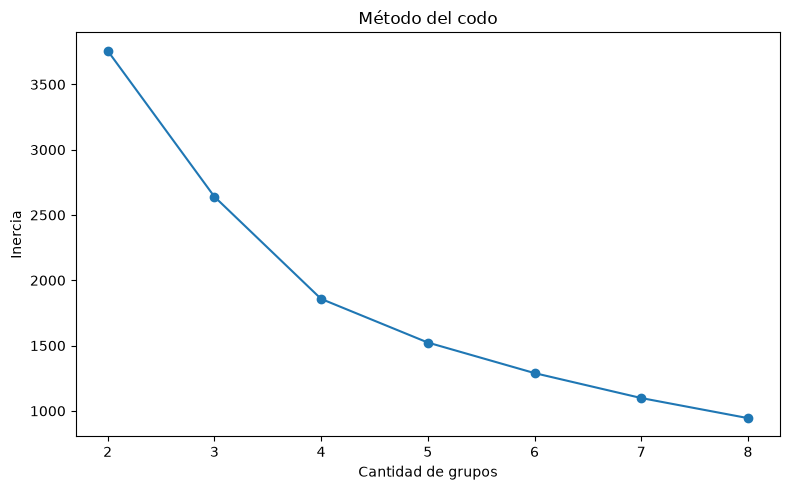

In [77]:
from sklearn.metrics import silhouette_score

inercias = []

valores_k = range(2, 9)

for k in valores_k:
    modelo_kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    modelo_kmeans.fit(datos_escalados)

    inercias.append(modelo_kmeans.inertia_)


plt.figure(figsize=(8, 5))

plt.plot(
    valores_k,
    inercias,
    marker="o"
)

plt.title("Método del codo")
plt.xlabel("Cantidad de grupos")
plt.ylabel("Inercia")

plt.xticks(valores_k)
plt.tight_layout()
plt.show()

In [78]:
silhouettes = []

valores_k = range(2, 9)

for k in valores_k:
    modelo_kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    grupos_temporales = modelo_kmeans.fit_predict(
        datos_escalados
    )

    puntuacion = silhouette_score(
        datos_escalados,
        grupos_temporales
    )

    silhouettes.append(puntuacion)

pd.Series(
    silhouettes,
    index=valores_k,
    name="Silhouette"
).round(3)

2    0.439
3    0.397
4    0.413
5    0.377
6    0.363
7    0.368
8    0.372
Name: Silhouette, dtype: float64

**Cantidad de segmentos:** El método del codo sugirió una solución de cuatro grupos. Aunque el mayor coeficiente silhouette se obtuvo con dos grupos (0,439), la solución de cuatro presentó un valor cercano (0,413) y permite obtener perfiles comerciales más detallados. Por esta razón, se seleccionaron cuatro segmentos, sujetos a una posterior evaluación de su tamaño y características.

In [79]:
modelo_final = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

grupos_clientes = modelo_final.fit_predict(
    datos_escalados
)

resumen_clientes["cluster"] = grupos_clientes

resumen_clientes[
    [
        "Customer ID",
        "recencia_dias",
        "compras_registradas",
        "gasto_total_usd",
        "cluster"
    ]
].head()

,Customer ID,recencia_dias,compras_registradas,gasto_total_usd,cluster
0,1,175,15,857.9,0
1,2,41,3,188.5,0
2,3,2,24,1262.4,2
3,4,0,50,2675.0,1
4,5,4,32,1785.5,1


In [80]:
perfil_clusters = (
    resumen_clientes
    .groupby("cluster")
    .agg(
        clientes=("Customer ID", "count"),
        recencia_mediana=("recencia_dias", "median"),
        recencia_promedio=("recencia_dias", "mean"),
        compras_promedio=("compras_registradas", "mean"),
        gasto_total_promedio=("gasto_total_usd", "mean"),
        abandono_porcentaje=("abandono", "mean")
    )
)

perfil_clusters["porcentaje_clientes"] = (
    perfil_clusters["clientes"]
    / len(resumen_clientes)
    * 100
)

perfil_clusters["abandono_porcentaje"] = (
    perfil_clusters["abandono_porcentaje"]
    * 100
)

perfil_clusters = perfil_clusters[
    [
        "clientes",
        "porcentaje_clientes",
        "recencia_mediana",
        "recencia_promedio",
        "compras_promedio",
        "gasto_total_promedio",
        "abandono_porcentaje"
    ]
].round(2)

perfil_clusters

,clientes,porcentaje_clientes,recencia_mediana,recencia_promedio,compras_promedio,gasto_total_promedio,abandono_porcentaje
cluster,,,,,,,
0,1084,27.79,90.5,120.09,10.54,535.96,18.08
1,1091,27.97,4.0,5.37,41.66,2189.28,0.00
2,869,22.28,6.0,7.24,18.87,994.55,0.00
3,856,21.95,33.0,43.42,34.47,1750.29,16.12


In [81]:
nombres_segmentos = {
    0: "Clientes de baja actividad",
    1: "Clientes de alto valor activos",
    2: "Clientes recientes en desarrollo",
    3: "Clientes valiosos en riesgo"
}

resumen_clientes["segmento"] = (
    resumen_clientes["cluster"]
    .map(nombres_segmentos)
)

resumen_clientes[
    [
        "Customer ID",
        "cluster",
        "segmento",
        "recencia_dias",
        "compras_registradas",
        "gasto_total_usd"
    ]
].head()

,Customer ID,cluster,segmento,recencia_dias,compras_registradas,gasto_total_usd
0,1,0,Clientes de baja actividad,175,15,857.9
1,2,0,Clientes de baja actividad,41,3,188.5
2,3,2,Clientes recientes en desarrollo,2,24,1262.4
3,4,1,Clientes de alto valor activos,0,50,2675.0
4,5,1,Clientes de alto valor activos,4,32,1785.5


### Visualización de los segmentos de clientes

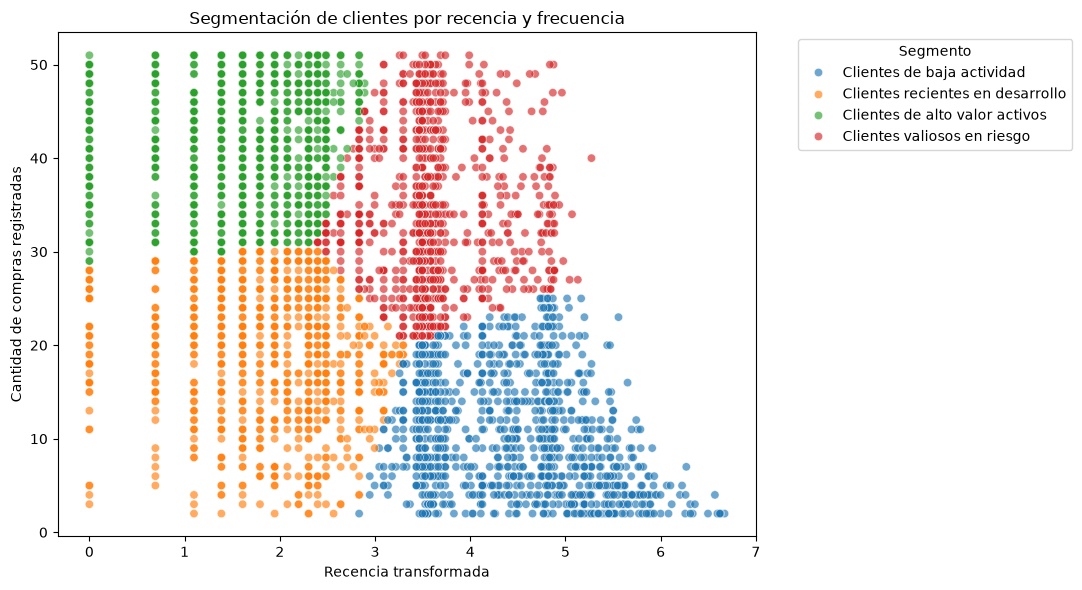

In [82]:
resumen_clientes["recencia_log"] = np.log1p(
    resumen_clientes["recencia_dias"]
)

plt.figure(figsize=(11, 6))

sns.scatterplot(
    data=resumen_clientes,
    x="recencia_log",
    y="compras_registradas",
    hue="segmento",
    alpha=0.65
)

plt.title("Segmentación de clientes por recencia y frecuencia")
plt.xlabel("Recencia transformada")
plt.ylabel("Cantidad de compras registradas")

plt.legend(
    title="Segmento",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

**Nota:** Para mejorar la visualización se utilizó la recencia transformada mediante logaritmo. Esta es la misma variable empleada para entrenar el modelo de segmentación. Los valores originales en días se conservaron para interpretar los perfiles comerciales.

### Estrategias comerciales por segmento

- **Clientes de alto valor activos:** conservar su fidelidad mediante beneficios exclusivos, acceso anticipado a productos y programas de recompensas.

- **Clientes recientes en desarrollo:** incentivar una segunda o próxima compra mediante recomendaciones personalizadas, promociones moderadas y comunicaciones de seguimiento.

- **Clientes valiosos en riesgo:** aplicar campañas de recuperación prioritarias, recordatorios y promociones personalizadas, ya que anteriormente compraron y gastaron bastante.

- **Clientes de baja actividad:** utilizar campañas de reactivación de bajo costo y evaluar su respuesta antes de invertir recursos comerciales mayores.

In [83]:
ruta_segmentos = "../datos/clientes_segmentados.csv"

resumen_clientes.to_csv(
    ruta_segmentos,
    index=False
)

print("Archivo guardado en:", ruta_segmentos)
print("Cantidad de clientes guardados:", len(resumen_clientes))

Archivo guardado en: ../datos/clientes_segmentados.csv
Cantidad de clientes guardados: 3900


## 6. Predicción del abandono

En esta sección se evalúa la posibilidad de identificar clientes asociados al abandono. Antes de entrenar los modelos, se analiza una posible fuga de información relacionada con la recencia. Luego se comparan dos modelos de regresión logística: uno sin recencia y otro que incorpora esta variable.

In [84]:
comparacion_recencia_abandono = (
    resumen_clientes
    .groupby("abandono")["recencia_dias"]
    .describe()
    .round(2)
)

comparacion_recencia_abandono

,count,mean,std,min,25%,50%,75%,max
abandono,,,,,,,,
0,3566.0,33.03,50.75,0.0,5.0,11.0,36.0,382.0
1,334.0,184.72,131.01,51.0,114.0,130.5,231.5,788.0


In [85]:
umbral_recencia = resumen_clientes["recencia_dias"] > 50

tabla_umbral_abandono = pd.crosstab(
    umbral_recencia,
    resumen_clientes["abandono"],
    margins=True
)

tabla_umbral_abandono

abandono,0,1,All
recencia_dias,,,
False,2958,0,2958
True,608,334,942
All,3566,334,3900


**Posible fuga de información:** Ningún cliente con una recencia igual o inferior a 50 días fue clasificado como abandono. Los 334 clientes que abandonaron presentaron más de 50 días desde su última compra. Sin embargo, también hubo 608 clientes con más de 50 días de recencia que no abandonaron. Esto sugiere que la recencia podría formar parte de la regla utilizada para construir la variable `Churn`, por lo que se compararán modelos con y sin esta variable.

In [86]:
y = resumen_clientes["abandono"]

y.value_counts()

abandono
0    3566
1     334
Name: count, dtype: int64

In [87]:
variables_base = [
    "edad",
    "compras_registradas",
    "gasto_promedio_usd",
    "genero",
    "suscripcion"
]

X_sin_recencia = resumen_clientes[
    variables_base
].copy()

X_con_recencia = resumen_clientes[
    variables_base + ["recencia_log"]
].copy()

print("Sin recencia:", X_sin_recencia.shape)
print("Con recencia:", X_con_recencia.shape)

X_sin_recencia.head()

Sin recencia: (3900, 5)
Con recencia: (3900, 6)


,edad,compras_registradas,gasto_promedio_usd,genero,suscripcion
0,55,15,57.19,Male,Yes
1,19,3,62.83,Male,Yes
2,50,24,52.60,Male,Yes
3,21,50,53.50,Male,Yes
4,45,32,55.80,Male,Yes


In [88]:
(
    X_sin_train,
    X_sin_test,
    X_con_train,
    X_con_test,
    y_train,
    y_test
) = train_test_split(
    X_sin_recencia,
    X_con_recencia,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Entrenamiento sin recencia:", X_sin_train.shape)
print("Prueba sin recencia:", X_sin_test.shape)

print("\nEntrenamiento con recencia:", X_con_train.shape)
print("Prueba con recencia:", X_con_test.shape)

print("\nAbandono en entrenamiento:")
print(y_train.value_counts())

print("\nAbandono en prueba:")
print(y_test.value_counts())

Entrenamiento sin recencia: (3120, 5)
Prueba sin recencia: (780, 5)

Entrenamiento con recencia: (3120, 6)
Prueba con recencia: (780, 6)

Abandono en entrenamiento:
abandono
0    2853
1     267
Name: count, dtype: int64

Abandono en prueba:
abandono
0    713
1     67
Name: count, dtype: int64


In [89]:
columnas_categoricas = [
    "genero",
    "suscripcion"
]

columnas_numericas_sin_recencia = [
    "edad",
    "compras_registradas",
    "gasto_promedio_usd"
]

columnas_numericas_con_recencia = [
    "edad",
    "compras_registradas",
    "gasto_promedio_usd",
    "recencia_log"
]


preprocesador_sin_recencia = ColumnTransformer(
    transformers=[
        (
            "numericas",
            StandardScaler(),
            columnas_numericas_sin_recencia
        ),
        (
            "categoricas",
            OneHotEncoder(handle_unknown="ignore"),
            columnas_categoricas
        )
    ]
)


preprocesador_con_recencia = ColumnTransformer(
    transformers=[
        (
            "numericas",
            StandardScaler(),
            columnas_numericas_con_recencia
        ),
        (
            "categoricas",
            OneHotEncoder(handle_unknown="ignore"),
            columnas_categoricas
        )
    ]
)

print("Preprocesadores creados correctamente.")

Preprocesadores creados correctamente.


In [90]:
modelo_sin_recencia = Pipeline(
    steps=[
        (
            "preprocesamiento",
            preprocesador_sin_recencia
        ),
        (
            "modelo",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

modelo_con_recencia = Pipeline(
    steps=[
        (
            "preprocesamiento",
            preprocesador_con_recencia
        ),
        (
            "modelo",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [91]:
modelo_sin_recencia.fit(
    X_sin_train,
    y_train
)

modelo_con_recencia.fit(
    X_con_train,
    y_train
)

print("Los dos modelos fueron entrenados correctamente.")

Los dos modelos fueron entrenados correctamente.


In [92]:
prediccion_sin_recencia = modelo_sin_recencia.predict(
    X_sin_test
)

prediccion_con_recencia = modelo_con_recencia.predict(
    X_con_test
)

print("Predicciones realizadas correctamente.")

Predicciones realizadas correctamente.


In [93]:
matriz_sin_recencia = pd.DataFrame(
    confusion_matrix(
        y_test,
        prediccion_sin_recencia
    ),
    index=[
        "Real: no abandono",
        "Real: abandono"
    ],
    columns=[
        "Predicho: no abandono",
        "Predicho: abandono"
    ]
)

matriz_sin_recencia

,Predicho: no abandono,Predicho: abandono
Real: no abandono,415,298
Real: abandono,34,33


In [94]:
matriz_con_recencia = pd.DataFrame(
    confusion_matrix(
        y_test,
        prediccion_con_recencia
    ),
    index=[
        "Real: no abandono",
        "Real: abandono"
    ],
    columns=[
        "Predicho: no abandono",
        "Predicho: abandono"
    ]
)

matriz_con_recencia

,Predicho: no abandono,Predicho: abandono
Real: no abandono,664,49
Real: abandono,1,66


In [95]:
print("MODELO SIN RECENCIA")
print(
    classification_report(
        y_test,
        prediccion_sin_recencia,
        target_names=["No abandono", "Abandono"]
    )
)

print("\nMODELO CON RECENCIA")
print(
    classification_report(
        y_test,
        prediccion_con_recencia,
        target_names=["No abandono", "Abandono"]
    )
)

MODELO SIN RECENCIA
              precision    recall  f1-score   support

 No abandono       0.92      0.58      0.71       713
    Abandono       0.10      0.49      0.17        67

    accuracy                           0.57       780
   macro avg       0.51      0.54      0.44       780
weighted avg       0.85      0.57      0.67       780


MODELO CON RECENCIA
              precision    recall  f1-score   support

 No abandono       1.00      0.93      0.96       713
    Abandono       0.57      0.99      0.73        67

    accuracy                           0.94       780
   macro avg       0.79      0.96      0.84       780
weighted avg       0.96      0.94      0.94       780



### Comparación de los modelos de abandono

El modelo sin recencia presentó un rendimiento limitado. Detectó el 49 % de los abandonos reales, pero solamente el 10 % de sus alertas correspondió a clientes que realmente abandonaron. Su F1-score para la clase abandono fue de 0,17.

Al incorporar la recencia, el modelo detectó el 99 % de los abandonos, alcanzó una precisión del 57 % y obtuvo un F1-score de 0,73. La exactitud general aumentó del 57 % al 94 %.

La mejora demuestra que el tiempo transcurrido desde la última compra concentra gran parte de la información asociada al abandono. Sin embargo, debido a que ningún abandono presentó una recencia inferior o igual a 50 días, existe la posibilidad de que esta variable haya formado parte de la definición original de `Churn`. Por ello, el rendimiento del modelo con recencia debe interpretarse con cautela y no como evidencia definitiva de capacidad predictiva futura.

In [96]:
probabilidad_sin_recencia = modelo_sin_recencia.predict_proba(
    X_sin_test
)[:, 1]

probabilidad_con_recencia = modelo_con_recencia.predict_proba(
    X_con_test
)[:, 1]

auc_sin_recencia = roc_auc_score(
    y_test,
    probabilidad_sin_recencia
)

auc_con_recencia = roc_auc_score(
    y_test,
    probabilidad_con_recencia
)

print("ROC-AUC sin recencia:", round(auc_sin_recencia, 3))
print("ROC-AUC con recencia:", round(auc_con_recencia, 3))

ROC-AUC sin recencia: 0.575
ROC-AUC con recencia: 0.986


### Evaluación mediante ROC-AUC

El modelo sin recencia obtuvo un ROC-AUC de 0,575, lo que indica una capacidad de discriminación limitada y apenas superior al azar.

Al incorporar la recencia, el ROC-AUC aumentó a 0,986, mostrando una separación casi perfecta entre clientes con y sin abandono. Este resultado confirma que el tiempo transcurrido desde la última compra concentra gran parte de la información asociada al abandono.

No obstante, debido a la posible relación entre la definición de `Churn` y la recencia, este rendimiento podría estar parcialmente influido por una fuga de información. Por este motivo, el valor de 0,986 no debe interpretarse como evidencia definitiva de que el modelo tendrá el mismo rendimiento con clientes futuros.

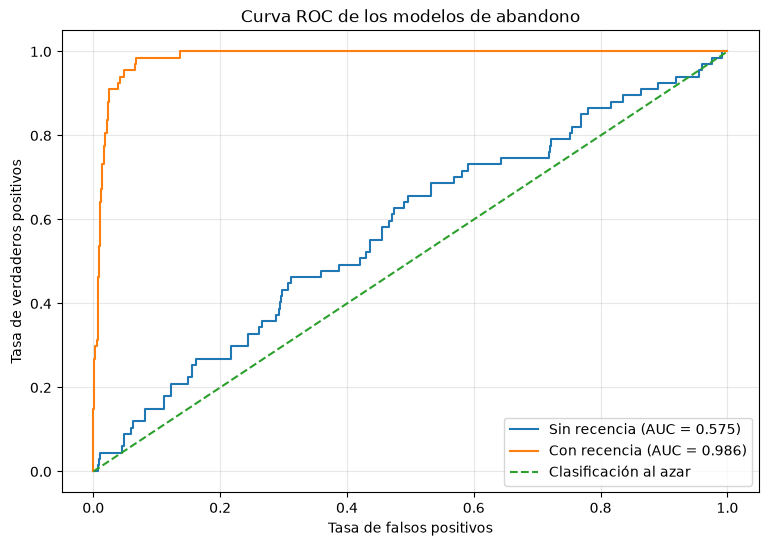

In [106]:

falsos_positivos_sin, verdaderos_positivos_sin, _ = roc_curve(
    y_test,
    probabilidad_sin_recencia
)

falsos_positivos_con, verdaderos_positivos_con, _ = roc_curve(
    y_test,
    probabilidad_con_recencia
)

plt.figure(figsize=(9, 6))

plt.plot(
    falsos_positivos_sin,
    verdaderos_positivos_sin,
    label=f"Sin recencia (AUC = {auc_sin_recencia:.3f})"
)

plt.plot(
    falsos_positivos_con,
    verdaderos_positivos_con,
    label=f"Con recencia (AUC = {auc_con_recencia:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificación al azar"
)

plt.title("Curva ROC de los modelos de abandono")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(
    "../imagenes/curva_roc_modelos.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [98]:
resultado_importancia = permutation_importance(
    modelo_con_recencia,
    X_con_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42
)

importancia_variables = pd.DataFrame({
    "variable": X_con_test.columns,
    "importancia": resultado_importancia.importances_mean
})

importancia_variables = (
    importancia_variables
    .sort_values(
        by="importancia",
        ascending=False
    )
    .reset_index(drop=True)
)

importancia_variables.round(3)

,variable,importancia
0,recencia_log,0.512
1,compras_registradas,0.068
2,suscripcion,0.000
3,genero,0.000
4,gasto_promedio_usd,-0.000
5,edad,-0.000


### Importancia de las variables

La importancia por permutación mostró que `recencia_log` fue la variable dominante, con una disminución promedio del ROC-AUC de 0,512 cuando sus valores fueron desordenados. La cantidad de compras presentó una importancia considerablemente menor, de 0,068.

La suscripción, el género, el gasto promedio y la edad mostraron importancias cercanas a cero, por lo que no aportaron capacidad discriminativa relevante al modelo una vez incorporadas la recencia y la frecuencia de compra.

Estos resultados describen la información utilizada por el modelo, pero no demuestran relaciones causales. Además, la elevada importancia de la recencia refuerza la advertencia sobre una posible relación entre esta variable y la definición original de `Churn`.

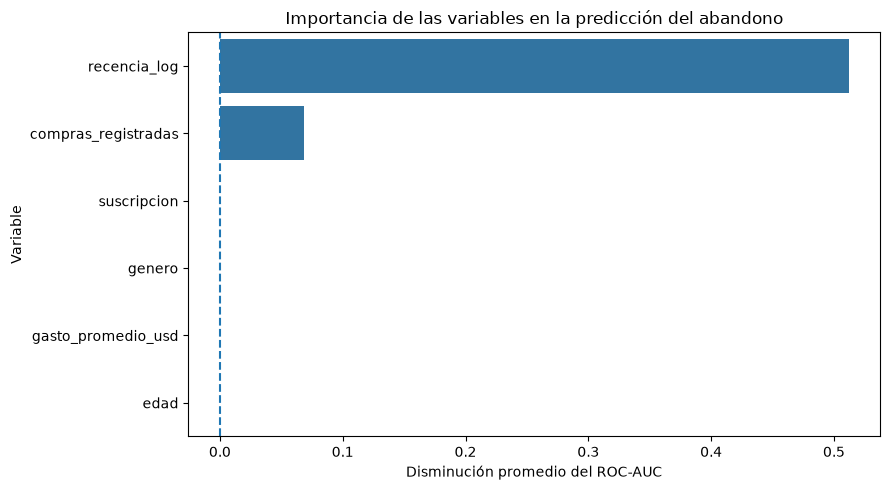

In [99]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=importancia_variables,
    x="importancia",
    y="variable"
)

plt.title("Importancia de las variables en la predicción del abandono")
plt.xlabel("Disminución promedio del ROC-AUC")
plt.ylabel("Variable")
plt.axvline(0, linestyle="--")
plt.tight_layout()
plt.show()

In [100]:
resultados_prueba = resumen_clientes.loc[
    X_con_test.index,
    [
        "Customer ID",
        "recencia_dias",
        "compras_registradas",
        "gasto_total_usd",
        "abandono"
    ]
].copy()

resultados_prueba["probabilidad_abandono"] = (
    probabilidad_con_recencia
)

resultados_prueba["abandono_predicho"] = (
    prediccion_con_recencia
)

resultados_prueba = (
    resultados_prueba
    .sort_values(
        by="probabilidad_abandono",
        ascending=False
    )
)

resultados_prueba.head(10)

,Customer ID,recencia_dias,compras_registradas,gasto_total_usd,abandono,probabilidad_abandono,abandono_predicho
2705,2706,749,2,77.0,1,0.999956,1
319,320,746,2,86.4,1,0.999941,1
1904,1905,142,47,2033.0,1,0.999924,1
331,332,129,47,2226.4,1,0.999814,1
2241,2242,493,4,180.5,1,0.999372,1
1463,1464,564,2,148.0,1,0.999346,1
1798,1799,550,2,140.8,1,0.999254,1
780,781,125,39,2097.2,1,0.998030,1
1241,1242,138,35,1734.0,1,0.997946,1
982,983,124,38,2032.8,1,0.997336,1


In [101]:
resultados_prueba = resultados_prueba.rename(
    columns={
        "probabilidad_abandono": "puntaje_riesgo_abandono"
    }
)

ruta_resultados = "../datos/evaluacion_riesgo_abandono.csv"

resultados_prueba.to_csv(
    ruta_resultados,
    index=False
)

print("Archivo guardado en:", ruta_resultados)
print("Clientes evaluados:", len(resultados_prueba))

Archivo guardado en: ../datos/evaluacion_riesgo_abandono.csv
Clientes evaluados: 780


In [102]:
comparacion_modelos = pd.DataFrame({
    "Modelo": [
        "Sin recencia",
        "Con recencia"
    ],
    "Accuracy": [
        accuracy_score(y_test, prediccion_sin_recencia),
        accuracy_score(y_test, prediccion_con_recencia)
    ],
    "Precision abandono": [
        precision_score(y_test, prediccion_sin_recencia),
        precision_score(y_test, prediccion_con_recencia)
    ],
    "Recall abandono": [
        recall_score(y_test, prediccion_sin_recencia),
        recall_score(y_test, prediccion_con_recencia)
    ],
    "F1 abandono": [
        f1_score(y_test, prediccion_sin_recencia),
        f1_score(y_test, prediccion_con_recencia)
    ],
    "ROC-AUC": [
        auc_sin_recencia,
        auc_con_recencia
    ]
})

comparacion_modelos.round(3)

,Modelo,Accuracy,Precision abandono,Recall abandono,F1 abandono,ROC-AUC
0,Sin recencia,0.574,0.100,0.493,0.166,0.575
1,Con recencia,0.936,0.574,0.985,0.725,0.986


In [103]:
ruta_metricas = "../datos/comparacion_modelos_abandono.csv"

comparacion_modelos.to_csv(
    ruta_metricas,
    index=False
)

print("Archivo guardado en:", ruta_metricas)

Archivo guardado en: ../datos/comparacion_modelos_abandono.csv


## 7. Conclusiones generales

El análisis incluyó 102.771 registros de compra correspondientes a 3.900 clientes, con operaciones realizadas entre 2022 y 2024.

### Evolución comercial

Las ventas totales alcanzaron aproximadamente USD 5,33 millones. Se observó un crecimiento sostenido:

- 2022: USD 1,45 millones.
- 2023: USD 1,73 millones.
- 2024: USD 2,16 millones.

El crecimiento estuvo explicado principalmente por el aumento de la cantidad de compras registradas y no por una variación importante del importe promedio por compra.

Diciembre fue el mes con mayores ventas en los tres años, mientras que septiembre presentó los valores más bajos.

### Categorías y productos

La categoría Clothing concentró aproximadamente el 67 % de las ventas. Su predominio se explicó principalmente por el volumen de compras y no por un importe promedio superior.

Los productos con mayores ventas fueron Sweater y Blouse, también impulsados principalmente por su frecuencia de compra.

### Comportamiento de los clientes

Los clientes realizaron, en promedio, 26 compras y acumularon un gasto aproximado de USD 1.367.

Los clientes que abandonaron presentaron:

- Menor cantidad promedio de compras.
- Menor gasto total.
- Mayor tiempo transcurrido desde la última compra.

La edad y el gasto promedio por compra mostraron diferencias pequeñas entre clientes con y sin abandono.

### Segmentación de clientes

Mediante KMeans se identificaron cuatro segmentos:

1. Clientes de alto valor activos.
2. Clientes recientes en desarrollo.
3. Clientes valiosos en riesgo.
4. Clientes de baja actividad.

Esta segmentación permite diseñar estrategias comerciales diferenciadas de fidelización, desarrollo, recuperación y reactivación.

### Predicción del abandono

Se compararon dos modelos de regresión logística:

- El modelo sin recencia obtuvo un ROC-AUC de 0,575 y mostró una capacidad predictiva limitada.
- El modelo con recencia obtuvo un ROC-AUC de 0,986, un recall de 0,985 y un F1-score de aproximadamente 0,73 para la clase abandono.

La importancia por permutación confirmó que la recencia fue la variable dominante, seguida a considerable distancia por la cantidad de compras.

### Limitaciones

El rendimiento del modelo con recencia debe interpretarse con cautela. Ningún cliente con 50 días o menos desde su última compra fue clasificado como abandono, lo que sugiere que la recencia podría haber formado parte de la definición original de `Churn`.

Por esta razón, el modelo demuestra principalmente una fuerte asociación entre inactividad y abandono, pero no garantiza el mismo rendimiento predictivo con clientes futuros.

Además, cada fila representa el registro de compra de un producto y no necesariamente una orden completa, debido a que el dataset no incluye un identificador de pedido.

### Aplicación comercial

Los resultados permiten:

- Reconocer los productos y períodos de mayor facturación.
- Identificar clientes de alto valor.
- Detectar clientes valiosos que muestran señales de inactividad.
- Priorizar campañas de retención según el riesgo estimado.
- Diferenciar las acciones comerciales para cada segmento de clientes.